# 问题二：FILT. NTU 自身历史项 + 截断到 2 的 History-only 模型

本 notebook 是第二问的一个**纯动态惯性模型**。

它只加入两件事：

```text
1. FILT. NTU 自身历史项
2. FILT. NTU 截断到 2
```

不使用 ARX。

也就是说，本 notebook 不加入任何外生变量：

```text
不使用 R/W NTU
不使用 R/W PH
不使用 ALUM
不使用 F/RIDE
不使用 R/W FLOW
不使用 rolling features
不使用 interaction features
不使用 residual correction
```


---

## 截断规则

```text
FILT. NTU_clip2 = min(FILT. NTU, 2)
```

所有超过 2 的 FILT. NTU 会被映射为 2。

---

## 模型比较

本 notebook 比较：

```text
AR1_clip2：过去 2 小时
AR3_clip2：过去 2、4、6 小时
AR6_clip2：过去 2–12 小时
AR12_clip2：过去 2–24 小时
```

每组训练：

```text
Linear Regression
Ridge
ElasticNet
```

---

## 输出目录

```text
outputs/problem2_history_only_clip2/
```

重点输出：

```text
problem2_history_only_clip2_model_results.xlsx
problem2_history_only_clip2_test_predictions.xlsx
problem2_history_only_clip2_coefficients.xlsx
problem2_history_only_clip2_final_summary.xlsx
figures/
models/
```


## 1. 导入依赖库

为了兼容旧版 scikit-learn，RMSE 使用：

```python
np.sqrt(mean_squared_error(y_true, y_pred))
```


In [1]:
from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

print("依赖库导入完成。")


依赖库导入完成。


## 2. 参数设置

目标变量：

```text
FILT. NTU
```

截断后目标：

```text
FILT. NTU_clip2
```

模型只使用 `FILT. NTU_clip2` 自身历史项。


In [2]:
TARGET_COL = "FILT. NTU"
CLIPPED_TARGET_COL = "FILT. NTU_clip2"

OUTPUT_DIR_NAME = "problem2_history_only_clip2"

RANDOM_STATE = 42
TRAIN_RATIO = 0.70
RECORD_INTERVAL_HOURS = 2

TARGET_CLIP_UPPER = 2.0

# 只测试 clipped FILT. NTU 自历史项，不加任何外生变量
AR_LAG_SETS = {
    "AR1_clip2": [1],
    "AR3_clip2": [1, 2, 3],
    "AR6_clip2": [1, 2, 3, 4, 5, 6],
    "AR12_clip2": list(range(1, 13)),
}

print("参数设置完成。")


参数设置完成。


## 3. 自动定位 `merged.xlsx`

本 notebook 从原始 `merged.xlsx` 读取。  
不依赖之前 P2 的任何中间文件。


In [3]:
def locate_merged_file(filename="merged.xlsx"):
    cwd = Path.cwd().resolve()
    candidates = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []

    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p

    for p in cwd.rglob(filename):
        return p.resolve()

    for parent in cwd.parents:
        try:
            for p in parent.rglob(filename):
                return p.resolve()
        except Exception:
            pass

    searched = "\n".join(str(p) for p in unique_candidates)
    raise FileNotFoundError(f"未找到 {filename}。已检查路径：\n{searched}")


DATA_PATH = locate_merged_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes
使用数据文件： E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
输出目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2


## 4. 读取数据并构造时间列

构造：

```text
DATETIME
OP_DATE
```

`OP_DATE` 使用前面问题一致的运行日定义：

```text
07:00 至次日 05:00 归为同一个运行日。
```


In [4]:
df = pd.read_excel(DATA_PATH)

print("原始数据规模：", df.shape)
print("原始列名：")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"未找到目标变量 {TARGET_COL}。请检查 merged.xlsx。")


def construct_datetime(data):
    data = data.copy()

    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data

    date_candidates = ["DATE", "Date", "date"]
    time_candidates = ["TIME", "Time", "time"]

    date_col = next((c for c in date_candidates if c in data.columns), None)
    time_col = next((c for c in time_candidates if c in data.columns), None)

    if date_col is None or time_col is None:
        raise ValueError("无法构造 DATETIME：需要 DATE 和 TIME 两列，或已有 DATETIME 列。")

    date_text = data[date_col].astype(str).str.split().str[0]
    time_text = data[time_col].astype(str).str.split().str[-1]

    data["DATETIME"] = pd.to_datetime(
        date_text + " " + time_text,
        errors="coerce",
    )

    return data


df = construct_datetime(df)
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

df["OP_DATE"] = df["DATETIME"].dt.date
mask_before_7 = df["DATETIME"].dt.hour < 7
df.loc[mask_before_7, "OP_DATE"] = (
    df.loc[mask_before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

print("时间范围：", df["DATETIME"].min(), "至", df["DATETIME"].max())
display(df[["DATETIME", "OP_DATE", TARGET_COL]].head(15))


原始数据规模： (5460, 18)
原始列名：
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00


,DATETIME,OP_DATE,FILT. NTU
0,2025-01-01 07:00:00,2025-01-01,0.04
1,2025-01-01 09:00:00,2025-01-01,0.05
2,2025-01-01 11:00:00,2025-01-01,0.05
3,2025-01-01 13:00:00,2025-01-01,0.05
4,2025-01-01 15:00:00,2025-01-01,0.05
5,2025-01-01 17:00:00,2025-01-01,0.06
6,2025-01-01 19:00:00,2025-01-01,0.05
7,2025-01-01 21:00:00,2025-01-01,0.05
8,2025-01-01 23:00:00,2025-01-01,0.05
9,2025-01-02 01:00:00,2025-01-01,0.05


## 5. 对 FILT. NTU 截断到 2

构造：

```text
FILT. NTU_clip2 = min(FILT. NTU, 2)
```

后续模型的目标和历史项都基于 `FILT. NTU_clip2`。


In [5]:
df[CLIPPED_TARGET_COL] = df[TARGET_COL].clip(upper=TARGET_CLIP_UPPER)

clip_audit = pd.DataFrame([
    {
        "item": "original_max",
        "value": df[TARGET_COL].max(skipna=True),
    },
    {
        "item": "clipped_max",
        "value": df[CLIPPED_TARGET_COL].max(skipna=True),
    },
    {
        "item": "count_above_2_before_clipping",
        "value": int((df[TARGET_COL] > TARGET_CLIP_UPPER).sum()),
    },
    {
        "item": "count_equal_2_after_clipping",
        "value": int((df[CLIPPED_TARGET_COL] == TARGET_CLIP_UPPER).sum()),
    },
    {
        "item": "clip_upper",
        "value": TARGET_CLIP_UPPER,
    },
])

clip_audit_path = OUTPUT_DIR / "problem2_history_only_clip2_clip_audit.xlsx"
clip_audit.to_excel(clip_audit_path, index=False)

print("截断审计表已保存：", clip_audit_path)

print("\n原始 FILT. NTU 描述统计：")
display(df[TARGET_COL].describe())

print("\n截断后 FILT. NTU_clip2 描述统计：")
display(df[CLIPPED_TARGET_COL].describe())

display(clip_audit)


截断审计表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_clip_audit.xlsx

原始 FILT. NTU 描述统计：


count    5460.000000
mean        0.190306
std         0.578003
min         0.020000
25%         0.040000
50%         0.060000
75%         0.110000
max         9.800000
Name: FILT. NTU, dtype: float64


截断后 FILT. NTU_clip2 描述统计：


count    5460.000000
mean        0.158245
std         0.316510
min         0.020000
25%         0.040000
50%         0.060000
75%         0.110000
max         2.000000
Name: FILT. NTU_clip2, dtype: float64

,item,value
0,original_max,9.8
1,clipped_max,2.0
2,count_above_2_before_clipping,89.0
3,count_equal_2_after_clipping,91.0
4,clip_upper,2.0


## 6. 数据审计

只审计：

```text
DATETIME
OP_DATE
FILT. NTU
FILT. NTU_clip2
```

输出：

```text
problem2_history_only_clip2_data_audit.xlsx
```


In [6]:
base_df = df[["DATETIME", "OP_DATE", TARGET_COL, CLIPPED_TARGET_COL]].copy()
base_df = base_df.dropna(subset=["DATETIME", CLIPPED_TARGET_COL]).sort_values("DATETIME").reset_index(drop=True)

audit_cols = ["DATETIME", "OP_DATE", TARGET_COL, CLIPPED_TARGET_COL]

audit_df = pd.DataFrame({
    "column": audit_cols,
    "dtype": [str(base_df[c].dtype) for c in audit_cols],
    "missing_count": [int(base_df[c].isna().sum()) for c in audit_cols],
    "missing_rate": [float(base_df[c].isna().mean()) for c in audit_cols],
    "unique_count": [int(base_df[c].nunique(dropna=True)) for c in audit_cols],
})

audit_path = OUTPUT_DIR / "problem2_history_only_clip2_data_audit.xlsx"
audit_df.to_excel(audit_path, index=False)

print("基础数据规模：", base_df.shape)
print("数据审计已保存：", audit_path)
display(audit_df)


基础数据规模： (5460, 4)
数据审计已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_data_audit.xlsx


,column,dtype,missing_count,missing_rate,unique_count
0,DATETIME,datetime64[us],0,0.0,5460
1,OP_DATE,object,0,0.0,455
2,FILT. NTU,float64,0,0.0,210
3,FILT. NTU_clip2,float64,0,0.0,138


## 7. 构造 `FILT. NTU_clip2` 自历史 lag 特征

只构造：

```text
FILT. NTU_clip2_lag1
FILT. NTU_clip2_lag2
...
FILT. NTU_clip2_lag12
```

不构造任何外生变量。

注意：

```text
不使用 FILT. NTU_clip2_lag0，因为 lag0 就是当前目标，会造成 target leakage。
```


In [7]:
feature_df = base_df.copy().sort_values("DATETIME").reset_index(drop=True)

max_lag = max(max(lags) for lags in AR_LAG_SETS.values())

lag_features = []

for lag in range(1, max_lag + 1):
    col_name = f"{CLIPPED_TARGET_COL}_lag{lag}"
    feature_df[col_name] = feature_df[CLIPPED_TARGET_COL].shift(lag)
    lag_features.append(col_name)

feature_summary_df = pd.DataFrame([
    {
        "feature": f"{CLIPPED_TARGET_COL}_lag{lag}",
        "source_variable": CLIPPED_TARGET_COL,
        "feature_type": "clipped_target_self_history_lag",
        "lag": lag,
        "lag_hours": lag * RECORD_INTERVAL_HOURS,
    }
    for lag in range(1, max_lag + 1)
])

feature_summary_path = OUTPUT_DIR / "problem2_history_only_clip2_feature_summary.xlsx"
feature_summary_df.to_excel(feature_summary_path, index=False)

print("已构造 clipped 自历史特征数：", len(lag_features))
print("特征说明已保存：", feature_summary_path)
display(feature_summary_df)


已构造 clipped 自历史特征数： 12
特征说明已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_feature_summary.xlsx


,feature,source_variable,feature_type,lag,lag_hours
0,FILT. NTU_clip2_lag1,FILT. NTU_clip2,clipped_target_self_history_lag,1,2
1,FILT. NTU_clip2_lag2,FILT. NTU_clip2,clipped_target_self_history_lag,2,4
2,FILT. NTU_clip2_lag3,FILT. NTU_clip2,clipped_target_self_history_lag,3,6
3,FILT. NTU_clip2_lag4,FILT. NTU_clip2,clipped_target_self_history_lag,4,8
4,FILT. NTU_clip2_lag5,FILT. NTU_clip2,clipped_target_self_history_lag,5,10
5,FILT. NTU_clip2_lag6,FILT. NTU_clip2,clipped_target_self_history_lag,6,12
6,FILT. NTU_clip2_lag7,FILT. NTU_clip2,clipped_target_self_history_lag,7,14
7,FILT. NTU_clip2_lag8,FILT. NTU_clip2,clipped_target_self_history_lag,8,16
8,FILT. NTU_clip2_lag9,FILT. NTU_clip2,clipped_target_self_history_lag,9,18
9,FILT. NTU_clip2_lag10,FILT. NTU_clip2,clipped_target_self_history_lag,10,20


## 8. 构造建模数据

目标：

```text
target_FILT_NTU_clip2 = FILT. NTU_clip2_t
```

输入：

```text
不同 AR 阶数下的 FILT. NTU_clip2 历史项
```


In [8]:
model_data = feature_df[["DATETIME", "OP_DATE", TARGET_COL, CLIPPED_TARGET_COL] + lag_features].copy()
model_data = model_data.rename(columns={CLIPPED_TARGET_COL: "target_FILT_NTU_clip2"})

model_data = model_data.dropna(subset=["DATETIME", "target_FILT_NTU_clip2"]).sort_values("DATETIME").reset_index(drop=True)

model_data_path = OUTPUT_DIR / "problem2_history_only_clip2_model_data.xlsx"
model_data.to_excel(model_data_path, index=False)

print("建模数据规模：", model_data.shape)
print("建模数据已保存：", model_data_path)
display(model_data.head())


建模数据规模： (5460, 16)
建模数据已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_model_data.xlsx


,DATETIME,OP_DATE,FILT. NTU,target_FILT_NTU_clip2,FILT. NTU_clip2_lag1,FILT. NTU_clip2_lag2,FILT. NTU_clip2_lag3,FILT. NTU_clip2_lag4,FILT. NTU_clip2_lag5,FILT. NTU_clip2_lag6,FILT. NTU_clip2_lag7,FILT. NTU_clip2_lag8,FILT. NTU_clip2_lag9,FILT. NTU_clip2_lag10,FILT. NTU_clip2_lag11,FILT. NTU_clip2_lag12
0,2025-01-01 07:00:00,2025-01-01,0.04,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 09:00:00,2025-01-01,0.05,0.05,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01 11:00:00,2025-01-01,0.05,0.05,0.05,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-01 13:00:00,2025-01-01,0.05,0.05,0.05,0.05,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01 15:00:00,2025-01-01,0.05,0.05,0.05,0.05,0.05,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9. 时间顺序划分训练集和测试集

采用统一时间顺序划分：

```text
前 70% train
后 30% test
```


In [9]:
n = len(model_data)
split_idx = int(n * TRAIN_RATIO)

train_df = model_data.iloc[:split_idx].copy()
test_df = model_data.iloc[split_idx:].copy()

y_train = train_df["target_FILT_NTU_clip2"].values
y_test = test_df["target_FILT_NTU_clip2"].values

print("总样本数：", n)
print("训练集：", train_df.shape, train_df["DATETIME"].min(), "至", train_df["DATETIME"].max())
print("测试集：", test_df.shape, test_df["DATETIME"].min(), "至", test_df["DATETIME"].max())


总样本数： 5460
训练集： (3821, 16) 2025-01-01 07:00:00 至 2025-11-15 15:00:00
测试集： (1639, 16) 2025-11-15 17:00:00 至 2026-04-01 05:00:00


## 10. 定义模型和评价函数

模型包括：

```text
Linear Regression
Ridge
ElasticNet
```

这些模型用于解释 clipped FILT. NTU 的自回归动态惯性。


In [10]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mask = np.abs(y_true) > 1e-6
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_percent": mape,
    }


def build_models():
    models = {}

    models["Linear Regression"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])

    models["Ridge"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ])

    models["ElasticNet"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=RANDOM_STATE, max_iter=20000)),
    ])

    return models


print("模型和评价函数定义完成。")


模型和评价函数定义完成。


## 11. 训练不同 AR 阶数的 clipped history-only 模型

比较：

```text
AR1_clip2
AR3_clip2
AR6_clip2
AR12_clip2
```

每个 AR 阶数下训练：

```text
Linear Regression
Ridge
ElasticNet
```

输出：

```text
problem2_history_only_clip2_model_results.xlsx
problem2_history_only_clip2_test_predictions.xlsx
models/
```


In [11]:
results_records = []
prediction_frames = []
trained_models = {}

for ar_name, lags in AR_LAG_SETS.items():
    feature_cols = [f"{CLIPPED_TARGET_COL}_lag{lag}" for lag in lags]

    print("=" * 80)
    print(f"Training {ar_name}: features = {feature_cols}")
    print("=" * 80)

    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    models = build_models()

    for model_name, model in models.items():
        print(f"Training {ar_name} - {model_name} ...")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_regression(y_test, y_pred)

        record = {
            "feature_set": ar_name,
            "model": model_name,
            "lags": ",".join(map(str, lags)),
            "lag_hours": ",".join(map(str, [lag * RECORD_INTERVAL_HOURS for lag in lags])),
            "n_features": len(feature_cols),
            "train_samples": len(X_train),
            "test_samples": len(X_test),
            **metrics,
        }

        results_records.append(record)

        pred_df = test_df[["DATETIME", "OP_DATE", TARGET_COL, "target_FILT_NTU_clip2"]].copy()
        pred_df["feature_set"] = ar_name
        pred_df["model"] = model_name
        pred_df["predicted_FILT_NTU_clip2"] = y_pred
        pred_df["residual_clip2"] = pred_df["target_FILT_NTU_clip2"] - pred_df["predicted_FILT_NTU_clip2"]
        prediction_frames.append(pred_df)

        key = f"{ar_name}__{model_name}"
        trained_models[key] = {
            "model": model,
            "features": feature_cols,
            "metrics": metrics,
        }

        model_path = MODEL_DIR / f"p2_history_only_clip2_{ar_name}_{model_name}.joblib".replace(" ", "_")
        joblib.dump({
            "model": model,
            "feature_cols": feature_cols,
            "target_col": "target_FILT_NTU_clip2",
            "feature_set": ar_name,
            "model_name": model_name,
            "metrics": metrics,
        }, model_path)

        print(f"  MAE={metrics['MAE']:.6f}, RMSE={metrics['RMSE']:.6f}, R2={metrics['R2']:.6f}")

results_df = pd.DataFrame(results_records).sort_values(["RMSE", "MAE"], ascending=[True, True]).reset_index(drop=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

results_path = OUTPUT_DIR / "problem2_history_only_clip2_model_results.xlsx"
predictions_path = OUTPUT_DIR / "problem2_history_only_clip2_test_predictions.xlsx"

results_df.to_excel(results_path, index=False)
predictions_df.to_excel(predictions_path, index=False)

print("模型结果已保存：", results_path)
print("测试集预测已保存：", predictions_path)
display(results_df)


Training AR1_clip2: features = ['FILT. NTU_clip2_lag1']
Training AR1_clip2 - Linear Regression ...
  MAE=0.043700, RMSE=0.167090, R2=0.653215
Training AR1_clip2 - Ridge ...
  MAE=0.043715, RMSE=0.167077, R2=0.653270
Training AR1_clip2 - ElasticNet ...
  MAE=0.044596, RMSE=0.166407, R2=0.656045
Training AR3_clip2: features = ['FILT. NTU_clip2_lag1', 'FILT. NTU_clip2_lag2', 'FILT. NTU_clip2_lag3']
Training AR3_clip2 - Linear Regression ...
  MAE=0.044027, RMSE=0.166499, R2=0.655662
Training AR3_clip2 - Ridge ...
  MAE=0.044045, RMSE=0.166489, R2=0.655705
Training AR3_clip2 - ElasticNet ...
  MAE=0.044995, RMSE=0.166093, R2=0.657340
Training AR6_clip2: features = ['FILT. NTU_clip2_lag1', 'FILT. NTU_clip2_lag2', 'FILT. NTU_clip2_lag3', 'FILT. NTU_clip2_lag4', 'FILT. NTU_clip2_lag5', 'FILT. NTU_clip2_lag6']
Training AR6_clip2 - Linear Regression ...
  MAE=0.043942, RMSE=0.165884, R2=0.658200
Training AR6_clip2 - Ridge ...
  MAE=0.043957, RMSE=0.165864, R2=0.658286
Training AR6_clip2 - Elast

,feature_set,model,lags,lag_hours,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,AR12_clip2,ElasticNet,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.044573,0.164501,0.663877,29.936327
1,AR6_clip2,ElasticNet,"1,2,3,4,5,6","2,4,6,8,10,12",6,3821,1639,0.044778,0.165057,0.661602,30.147229
2,AR12_clip2,Ridge,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.044159,0.165083,0.661495,28.846629
3,AR12_clip2,Linear Regression,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.044150,0.165103,0.661412,28.829458
4,AR6_clip2,Ridge,"1,2,3,4,5,6","2,4,6,8,10,12",6,3821,1639,0.043957,0.165864,0.658286,28.559645
5,AR6_clip2,Linear Regression,"1,2,3,4,5,6","2,4,6,8,10,12",6,3821,1639,0.043942,0.165884,0.658200,28.535803
6,AR3_clip2,ElasticNet,"1,2,3","2,4,6",3,3821,1639,0.044995,0.166093,0.657340,30.255403
7,AR1_clip2,ElasticNet,1,2,1,3821,1639,0.044596,0.166407,0.656045,30.538498
8,AR3_clip2,Ridge,"1,2,3","2,4,6",3,3821,1639,0.044045,0.166489,0.655705,28.607347
9,AR3_clip2,Linear Regression,"1,2,3","2,4,6",3,3821,1639,0.044027,0.166499,0.655662,28.581388


## 12. 提取线性模型系数

系数用于解释：

```text
FILT. NTU_clip2_lag1
FILT. NTU_clip2_lag2
...
```

对当前截断后 FILT. NTU 的影响强度和方向。

输出：

```text
problem2_history_only_clip2_coefficients.xlsx
```


In [12]:
coef_records = []

for key, item in trained_models.items():
    ar_name, model_name = key.split("__", 1)

    model = item["model"]
    feature_cols = item["features"]
    estimator = model.named_steps["model"]

    if not hasattr(estimator, "coef_"):
        continue

    coef_temp = pd.DataFrame({
        "feature_set": ar_name,
        "model": model_name,
        "feature": feature_cols,
        "coefficient": estimator.coef_,
    })

    coef_temp["abs_coefficient"] = coef_temp["coefficient"].abs()
    coef_temp = coef_temp.sort_values("abs_coefficient", ascending=False)

    coef_records.append(coef_temp)

coef_df = pd.concat(coef_records, ignore_index=True) if coef_records else pd.DataFrame()

coef_path = OUTPUT_DIR / "problem2_history_only_clip2_coefficients.xlsx"
coef_df.to_excel(coef_path, index=False)

print("系数表已保存：", coef_path)
display(coef_df.head(60))


系数表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_coefficients.xlsx


,feature_set,model,feature,coefficient,abs_coefficient
0,AR1_clip2,Linear Regression,FILT. NTU_clip2_lag1,0.305847,0.305847
1,AR1_clip2,Ridge,FILT. NTU_clip2_lag1,0.305767,0.305767
2,AR1_clip2,ElasticNet,FILT. NTU_clip2_lag1,0.301435,0.301435
3,AR3_clip2,Linear Regression,FILT. NTU_clip2_lag1,0.289399,0.289399
4,AR3_clip2,Linear Regression,FILT. NTU_clip2_lag3,0.020691,0.020691
5,AR3_clip2,Linear Regression,FILT. NTU_clip2_lag2,-0.001675,0.001675
6,AR3_clip2,Ridge,FILT. NTU_clip2_lag1,0.288845,0.288845
7,AR3_clip2,Ridge,FILT. NTU_clip2_lag3,0.020677,0.020677
8,AR3_clip2,Ridge,FILT. NTU_clip2_lag2,-0.001147,0.001147
9,AR3_clip2,ElasticNet,FILT. NTU_clip2_lag1,0.272915,0.272915


## 13. 与未截断 history-only 模型对比

如果存在：

```text
outputs/problem2_history_only/problem2_history_only_model_results.xlsx
```

则自动读取并对比：

```text
History-only 原始目标
vs
History-only clipped目标
```

这样可以判断截断到 2 是否改善了模型。


In [13]:
comparison_frames = []

clip_compare = results_df.copy()
clip_compare["version"] = "history_only_clip2"
comparison_frames.append(clip_compare)

raw_history_path = PROJECT_DIR / "outputs" / "problem2_history_only" / "problem2_history_only_model_results.xlsx"

if raw_history_path.exists():
    raw_compare = pd.read_excel(raw_history_path)
    raw_compare["version"] = "history_only_raw_target"
    comparison_frames.append(raw_compare)
    print("已读取未截断 history-only 结果：", raw_history_path)
else:
    print("未找到未截断 history-only 结果，跳过自动对比。")

common_cols = [
    "version",
    "feature_set",
    "model",
    "n_features",
    "MAE",
    "RMSE",
    "R2",
    "MAPE_percent",
]

comparison_df = pd.concat(
    [df_.reindex(columns=common_cols) for df_ in comparison_frames],
    ignore_index=True,
)

comparison_df = comparison_df.sort_values("RMSE", ascending=True).reset_index(drop=True)

comparison_path = OUTPUT_DIR / "problem2_history_only_clip2_comparison_with_raw.xlsx"
comparison_df.to_excel(comparison_path, index=False)

print("与未截断版本对比表已保存：", comparison_path)
display(comparison_df)


已读取未截断 history-only 结果： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_model_results.xlsx
与未截断版本对比表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_comparison_with_raw.xlsx


,version,feature_set,model,n_features,MAE,RMSE,R2,MAPE_percent
0,history_only_clip2,AR12_clip2,ElasticNet,12,0.044573,0.164501,0.663877,29.936327
1,history_only_clip2,AR6_clip2,ElasticNet,6,0.044778,0.165057,0.661602,30.147229
2,history_only_clip2,AR12_clip2,Ridge,12,0.044159,0.165083,0.661495,28.846629
3,history_only_clip2,AR12_clip2,Linear Regression,12,0.044150,0.165103,0.661412,28.829458
4,history_only_clip2,AR6_clip2,Ridge,6,0.043957,0.165864,0.658286,28.559645
5,history_only_clip2,AR6_clip2,Linear Regression,6,0.043942,0.165884,0.658200,28.535803
6,history_only_clip2,AR3_clip2,ElasticNet,3,0.044995,0.166093,0.657340,30.255403
7,history_only_clip2,AR1_clip2,ElasticNet,1,0.044596,0.166407,0.656045,30.538498
8,history_only_clip2,AR3_clip2,Ridge,3,0.044045,0.166489,0.655705,28.607347
9,history_only_clip2,AR3_clip2,Linear Regression,3,0.044027,0.166499,0.655662,28.581388


## 14. 判断截断是否带来提升

如果同时存在 raw history-only 结果，则按每个版本的最佳 RMSE / R² 比较。

输出：

```text
problem2_history_only_clip2_enhancement_judgement.xlsx
```


In [14]:
judgement_records = []

clip_best = results_df.iloc[0].copy()

if raw_history_path.exists():
    raw_results = pd.read_excel(raw_history_path).sort_values(["RMSE", "MAE"], ascending=[True, True]).reset_index(drop=True)
    raw_best = raw_results.iloc[0].copy()

    judgement_records.append({
        "comparison": "history_only_clip2 vs history_only_raw_target",
        "baseline": "history_only_raw_target",
        "candidate": "history_only_clip2",
        "baseline_best_feature_set": raw_best["feature_set"],
        "baseline_best_model": raw_best["model"],
        "candidate_best_feature_set": clip_best["feature_set"],
        "candidate_best_model": clip_best["model"],
        "baseline_RMSE": raw_best["RMSE"],
        "candidate_RMSE": clip_best["RMSE"],
        "RMSE_improvement": raw_best["RMSE"] - clip_best["RMSE"],
        "baseline_R2": raw_best["R2"],
        "candidate_R2": clip_best["R2"],
        "R2_improvement": clip_best["R2"] - raw_best["R2"],
        "is_improved": (clip_best["RMSE"] < raw_best["RMSE"]) and (clip_best["R2"] > raw_best["R2"]),
    })
else:
    judgement_records.append({
        "comparison": "history_only_clip2 only",
        "baseline": "not_available",
        "candidate": "history_only_clip2",
        "baseline_best_feature_set": np.nan,
        "baseline_best_model": np.nan,
        "candidate_best_feature_set": clip_best["feature_set"],
        "candidate_best_model": clip_best["model"],
        "baseline_RMSE": np.nan,
        "candidate_RMSE": clip_best["RMSE"],
        "RMSE_improvement": np.nan,
        "baseline_R2": np.nan,
        "candidate_R2": clip_best["R2"],
        "R2_improvement": np.nan,
        "is_improved": np.nan,
    })

enhancement_judgement_df = pd.DataFrame(judgement_records)

enhancement_judgement_path = OUTPUT_DIR / "problem2_history_only_clip2_enhancement_judgement.xlsx"
enhancement_judgement_df.to_excel(enhancement_judgement_path, index=False)

print("截断提升判断表已保存：", enhancement_judgement_path)
display(enhancement_judgement_df)


截断提升判断表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_enhancement_judgement.xlsx


,comparison,baseline,candidate,baseline_best_feature_set,baseline_best_model,candidate_best_feature_set,candidate_best_model,baseline_RMSE,candidate_RMSE,RMSE_improvement,baseline_R2,candidate_R2,R2_improvement,is_improved
0,history_only_clip2 vs history_only_raw_target,history_only_raw_target,history_only_clip2,AR12,Ridge,AR12_clip2,ElasticNet,0.24414,0.164501,0.079639,0.583975,0.663877,0.079902,True


## 15. 可视化：不同 AR 阶数模型性能

输出：

```text
figures/problem2_history_only_clip2_rmse_comparison.png
figures/problem2_history_only_clip2_r2_comparison.png
```


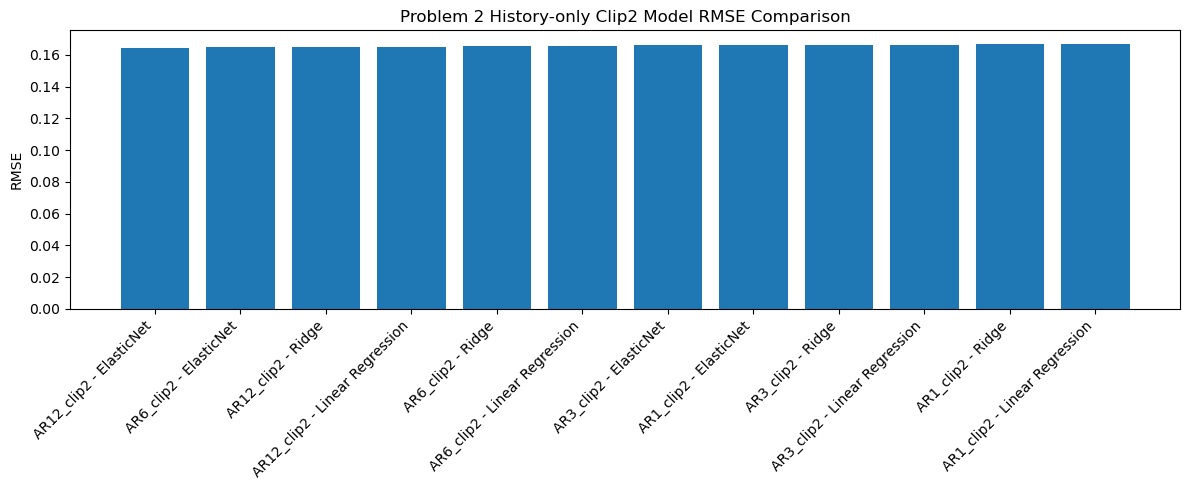

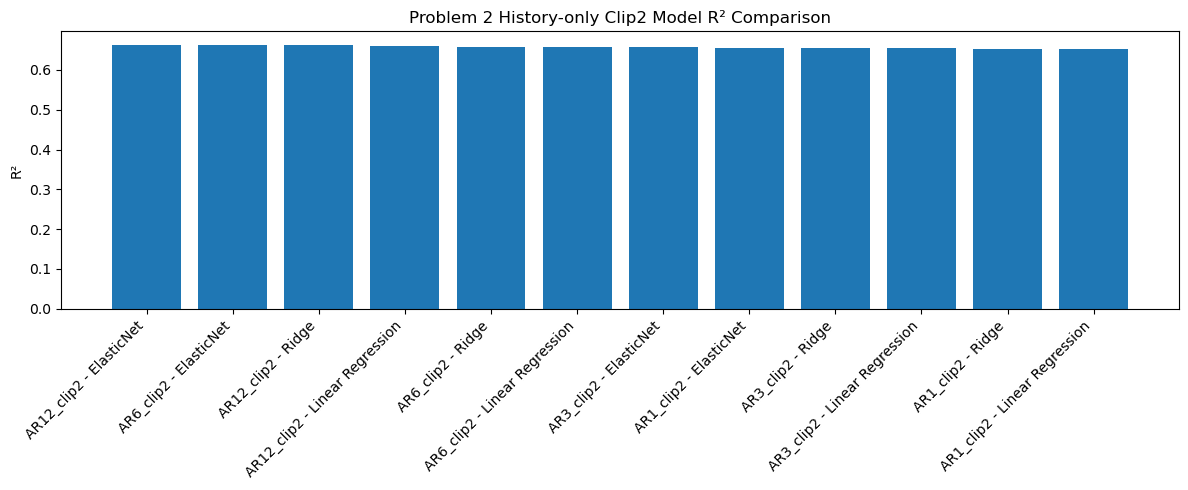

RMSE 图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\figures\problem2_history_only_clip2_rmse_comparison.png
R² 图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\figures\problem2_history_only_clip2_r2_comparison.png


In [15]:
plot_df = results_df.copy()
plot_df["label"] = plot_df["feature_set"] + " - " + plot_df["model"]

plt.figure(figsize=(12, 5))
plt.bar(plot_df["label"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Problem 2 History-only Clip2 Model RMSE Comparison")
plt.tight_layout()

rmse_fig_path = FIG_DIR / "problem2_history_only_clip2_rmse_comparison.png"
plt.savefig(rmse_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["label"], plot_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Problem 2 History-only Clip2 Model R² Comparison")
plt.tight_layout()

r2_fig_path = FIG_DIR / "problem2_history_only_clip2_r2_comparison.png"
plt.savefig(r2_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("RMSE 图已保存：", rmse_fig_path)
print("R² 图已保存：", r2_fig_path)


## 16. 可视化：最佳模型预测曲线和残差图

根据 RMSE 最小原则选择最佳 clipped history-only 模型。


最佳 clipped history-only 模型：


,feature_set,model,lags,lag_hours,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,AR12_clip2,ElasticNet,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.044573,0.164501,0.663877,29.936327


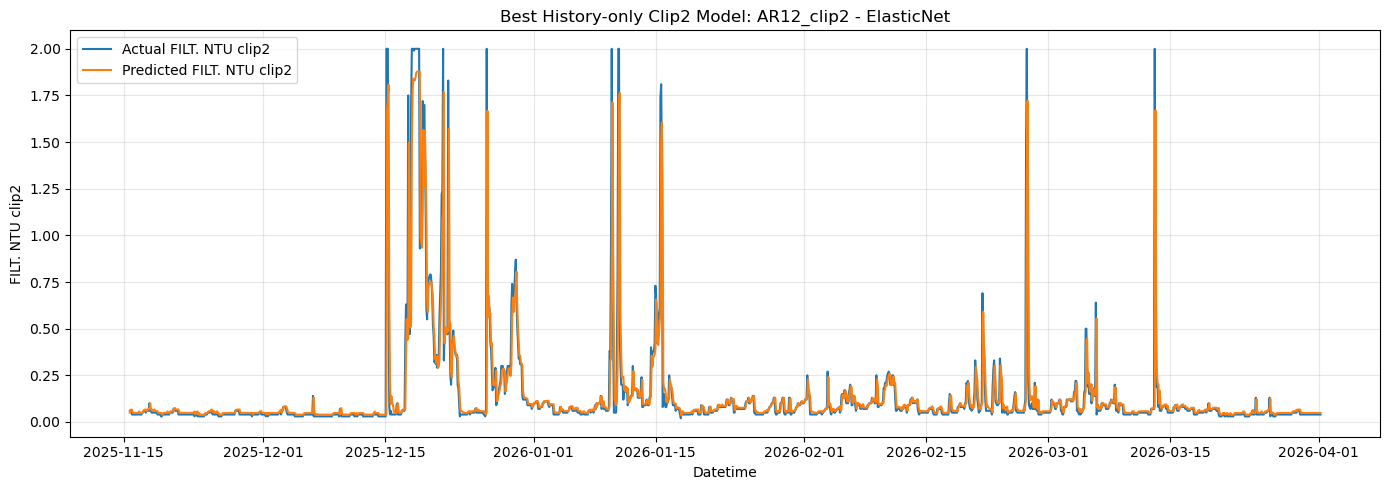

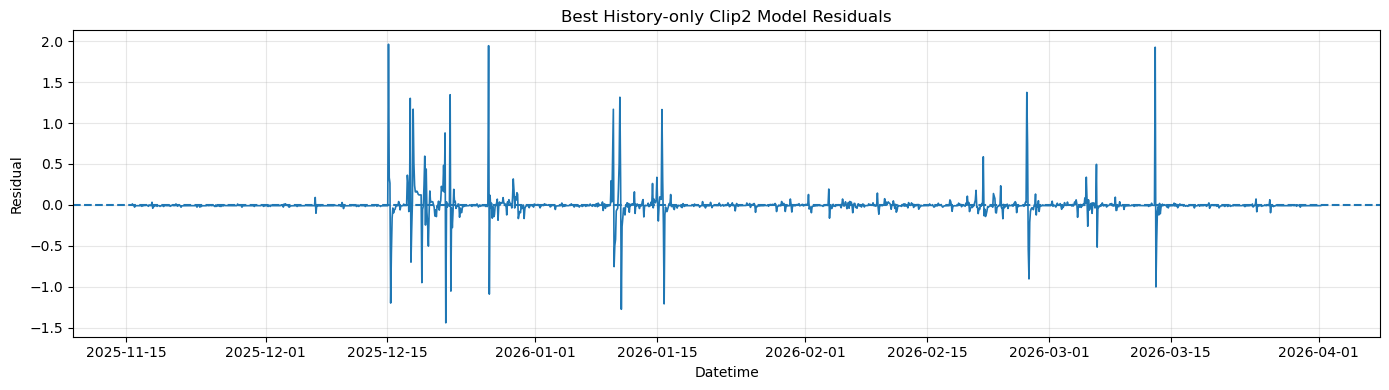

最佳模型预测图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\figures\problem2_history_only_clip2_best_model_timeseries.png
残差图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\figures\problem2_history_only_clip2_best_model_residuals.png


In [16]:
best_row = results_df.iloc[0]
best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]

best_pred_df = predictions_df[
    (predictions_df["feature_set"] == best_feature_set) &
    (predictions_df["model"] == best_model_name)
].copy()

print("最佳 clipped history-only 模型：")
display(best_row.to_frame().T)

plt.figure(figsize=(14, 5))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["target_FILT_NTU_clip2"],
    label="Actual FILT. NTU clip2",
    linewidth=1.5,
)
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["predicted_FILT_NTU_clip2"],
    label="Predicted FILT. NTU clip2",
    linewidth=1.5,
)
plt.title(f"Best History-only Clip2 Model: {best_feature_set} - {best_model_name}")
plt.xlabel("Datetime")
plt.ylabel("FILT. NTU clip2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

best_ts_fig_path = FIG_DIR / "problem2_history_only_clip2_best_model_timeseries.png"
plt.savefig(best_ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["residual_clip2"],
    linewidth=1.2,
)
plt.axhline(0, linestyle="--")
plt.title("Best History-only Clip2 Model Residuals")
plt.xlabel("Datetime")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.tight_layout()

residual_fig_path = FIG_DIR / "problem2_history_only_clip2_best_model_residuals.png"
plt.savefig(residual_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("最佳模型预测图已保存：", best_ts_fig_path)
print("残差图已保存：", residual_fig_path)


## 17. 输出汇总工作簿和最终摘要

输出：

```text
problem2_history_only_clip2_summary.xlsx
problem2_history_only_clip2_final_summary.xlsx
```


In [17]:
summary_workbook_path = OUTPUT_DIR / "problem2_history_only_clip2_summary.xlsx"

with pd.ExcelWriter(summary_workbook_path, engine="openpyxl") as writer:
    clip_audit.to_excel(writer, sheet_name="clip_audit", index=False)
    audit_df.to_excel(writer, sheet_name="data_audit", index=False)
    feature_summary_df.to_excel(writer, sheet_name="feature_summary", index=False)
    results_df.to_excel(writer, sheet_name="model_results", index=False)
    coef_df.to_excel(writer, sheet_name="coefficients", index=False)
    comparison_df.to_excel(writer, sheet_name="comparison_with_raw", index=False)
    enhancement_judgement_df.to_excel(writer, sheet_name="enhancement_judgement", index=False)

final_summary = pd.DataFrame([
    {
        "item": "model_family",
        "value": "FILT. NTU history-only autoregressive model with clipping at 2",
    },
    {
        "item": "target",
        "value": "FILT. NTU_clip2",
    },
    {
        "item": "clipping_rule",
        "value": f"FILT. NTU_clip2 = min(FILT. NTU, {TARGET_CLIP_UPPER})",
    },
    {
        "item": "input_variables",
        "value": "Only lagged FILT. NTU_clip2 terms. No exogenous variables are used.",
    },
    {
        "item": "best_feature_set",
        "value": best_feature_set,
    },
    {
        "item": "best_model",
        "value": best_model_name,
    },
    {
        "item": "best_MAE",
        "value": best_row["MAE"],
    },
    {
        "item": "best_RMSE",
        "value": best_row["RMSE"],
    },
    {
        "item": "best_R2",
        "value": best_row["R2"],
    },
    {
        "item": "interpretation",
        "value": "This model tests whether clipped FILT. NTU can be predicted from its own historical states, reflecting dynamic inertia.",
    },
])

final_summary_path = OUTPUT_DIR / "problem2_history_only_clip2_final_summary.xlsx"
final_summary.to_excel(final_summary_path, index=False)

print("汇总工作簿已保存：", summary_workbook_path)
print("最终摘要已保存：", final_summary_path)
display(final_summary)


汇总工作簿已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_summary.xlsx
最终摘要已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_final_summary.xlsx


,item,value
0,model_family,FILT. NTU history-only autoregressive model wi...
1,target,FILT. NTU_clip2
2,clipping_rule,"FILT. NTU_clip2 = min(FILT. NTU, 2.0)"
3,input_variables,Only lagged FILT. NTU_clip2 terms. No exogenou...
4,best_feature_set,AR12_clip2
5,best_model,ElasticNet
6,best_MAE,0.044573
7,best_RMSE,0.164501
8,best_R2,0.663877
9,interpretation,This model tests whether clipped FILT. NTU can...


## 18. 论文中可使用的表述

可以写：

```text
为单独检验滤后水浊度自身历史状态的动态解释能力，本文构建 history-only 自回归模型。该模型不引入原水浊度、pH、投药量或流量等外生变量，仅使用 FILT. NTU 的历史滞后项预测当前 FILT. NTU。同时，为降低极端浊度值对模型训练的影响，将 FILT. NTU 超过 2 的样本截断为 2，得到 FILT. NTU_clip2。若该模型在测试集上取得较高 R²，则说明滤后水浊度存在明显的短期动态惯性。
```

英文：

```text
To independently examine the dynamic explanatory power of the historical states of filtered water turbidity, a history-only autoregressive model was constructed. No exogenous variables such as raw-water turbidity, pH, chemical dosing, or flow rate were included. Only lagged FILT. NTU terms were used to predict the current FILT. NTU. In addition, FILT. NTU values greater than 2 were clipped to 2 to reduce the influence of extreme turbidity observations. A high test R² would indicate strong short-term dynamic inertia in filtered water turbidity.
```


In [18]:
print("=" * 80)
print("问题二 FILT. NTU 自历史项 + 截断到 2 的 History-only 模型已完成。")
print("=" * 80)

print("\n核心输出文件：")
print("1. clipping 审计：", clip_audit_path)
print("2. 数据审计：", audit_path)
print("3. 特征说明：", feature_summary_path)
print("4. 建模数据：", model_data_path)
print("5. 模型结果：", results_path)
print("6. 测试集预测：", predictions_path)
print("7. 系数表：", coef_path)
print("8. 与未截断版本对比：", comparison_path)
print("9. 截断提升判断：", enhancement_judgement_path)
print("10. 汇总工作簿：", summary_workbook_path)
print("11. 最终摘要：", final_summary_path)
print("12. 图片目录：", FIG_DIR)
print("13. 模型目录：", MODEL_DIR)

print("\n模型结果：")
display(results_df)

print("\n最佳 clipped history-only 模型：")
display(best_row.to_frame().T)

print("\n截断提升判断：")
display(enhancement_judgement_df)

print("\n最终摘要：")
display(final_summary)


问题二 FILT. NTU 自历史项 + 截断到 2 的 History-only 模型已完成。

核心输出文件：
1. clipping 审计： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_clip_audit.xlsx
2. 数据审计： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_data_audit.xlsx
3. 特征说明： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_feature_summary.xlsx
4. 建模数据： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_model_data.xlsx
5. 模型结果： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_model_results.xlsx
6. 测试集预测： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_test_predictions.xlsx
7. 系数表： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only_clip2\problem2_history_only_clip2_coefficients.xlsx
8. 与未截断版本对比： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_on

,feature_set,model,lags,lag_hours,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,AR12_clip2,ElasticNet,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.044573,0.164501,0.663877,29.936327
1,AR6_clip2,ElasticNet,"1,2,3,4,5,6","2,4,6,8,10,12",6,3821,1639,0.044778,0.165057,0.661602,30.147229
2,AR12_clip2,Ridge,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.044159,0.165083,0.661495,28.846629
3,AR12_clip2,Linear Regression,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.044150,0.165103,0.661412,28.829458
4,AR6_clip2,Ridge,"1,2,3,4,5,6","2,4,6,8,10,12",6,3821,1639,0.043957,0.165864,0.658286,28.559645
5,AR6_clip2,Linear Regression,"1,2,3,4,5,6","2,4,6,8,10,12",6,3821,1639,0.043942,0.165884,0.658200,28.535803
6,AR3_clip2,ElasticNet,"1,2,3","2,4,6",3,3821,1639,0.044995,0.166093,0.657340,30.255403
7,AR1_clip2,ElasticNet,1,2,1,3821,1639,0.044596,0.166407,0.656045,30.538498
8,AR3_clip2,Ridge,"1,2,3","2,4,6",3,3821,1639,0.044045,0.166489,0.655705,28.607347
9,AR3_clip2,Linear Regression,"1,2,3","2,4,6",3,3821,1639,0.044027,0.166499,0.655662,28.581388



最佳 clipped history-only 模型：


,feature_set,model,lags,lag_hours,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,AR12_clip2,ElasticNet,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.044573,0.164501,0.663877,29.936327



截断提升判断：


,comparison,baseline,candidate,baseline_best_feature_set,baseline_best_model,candidate_best_feature_set,candidate_best_model,baseline_RMSE,candidate_RMSE,RMSE_improvement,baseline_R2,candidate_R2,R2_improvement,is_improved
0,history_only_clip2 vs history_only_raw_target,history_only_raw_target,history_only_clip2,AR12,Ridge,AR12_clip2,ElasticNet,0.24414,0.164501,0.079639,0.583975,0.663877,0.079902,True



最终摘要：


,item,value
0,model_family,FILT. NTU history-only autoregressive model wi...
1,target,FILT. NTU_clip2
2,clipping_rule,"FILT. NTU_clip2 = min(FILT. NTU, 2.0)"
3,input_variables,Only lagged FILT. NTU_clip2 terms. No exogenou...
4,best_feature_set,AR12_clip2
5,best_model,ElasticNet
6,best_MAE,0.044573
7,best_RMSE,0.164501
8,best_R2,0.663877
9,interpretation,This model tests whether clipped FILT. NTU can...
